# Как я определяю автоматизированный сбор данных

Это финальная версия решения, v2. На скрытом тесте она получила
Precision при Recall ≥ 70% = 0.82278.

Ноутбук проходит весь путь от исходных событий до `submission.csv`.
В конце проверяется побайтовое совпадение с отправленным файлом.
Сохранённые ответы не используются при расчёте новых предсказаний.

## Подход в двух словах

Я смотрю не на одно событие, а на поведение куки за сутки. Сколько объявлений
она открывает? Как меняются интервалы между действиями? Есть ли поиск,
фотографии, контакты, возвращения к одному объявлению? Насколько однообразны
движения курсора там, где он вообще доступен?

Из этих наблюдений получается числовая строка. Исходные 250 признаков
описывают объём, разнообразие, паузы, сессии, поиск, курсор и устройство.
Ещё 222 признака уточняют ритм отдельных действий, воронку объявления,
пагинацию внутри одного запроса и геометрию движений.

Финальный score - среднее вероятностей двух CatBoost и двух LightGBM.
CatBoost использует 250 исходных признаков, LightGBM - все 472.
Равные веса выбраны по временной проверке и теперь зафиксированы.
Это обычные локальные модели: ни внешних API, ни языковых моделей здесь нет.

Отдельного порога в ответе не будет. Проверяющая система сама найдёт лучший
порог среди тех, где Recall не ниже 70%.

## Что нужно для запуска

Python 3.11.9. Из корня репозитория создайте `.venv`
и установите `requirements-notebook.txt` командами из README.
Выберите это окружение как ядро Jupyter или VS Code, затем выполните Run All.

Положите `train.csv`, `test.csv`, `events.csv.gz` в `data/` или поменяйте
`DATA_DIR` ниже. Сжатый файл распаковывать не нужно.

Полный запуск включает признаки, 12 обучений для временной проверки,
четыре финальных обучения и независимую пересборку тестовых признаков.

In [1]:
import os
import sys
import time
import platform
from pathlib import Path
from importlib.metadata import version

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
assert (ROOT / "bot_solution").is_dir(), "Откройте notebook из корня репозитория"
DATA_DIR = Path(os.environ.get("BOT_DATA_DIR", ROOT / "data")).resolve()
OUTPUT_DIR = ROOT / "outputs"
SUBMISSION_PATH = ROOT / "submission.csv"
THREADS = 8
OUTPUT_DIR.mkdir(exist_ok=True)

# Все служебные кеши остаются внутри выбранного Python-окружения.
os.environ.setdefault("MPLCONFIGDIR", str(Path(sys.prefix) / ".cache" / "matplotlib"))
np.random.seed(42)
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 5)

from bot_solution.pipeline import (
    load_prepared_data, build_feature_matrices, fit_final_models, predict_ensemble,
    save_submission, save_run_metadata, assert_reference_submission,
    reference_metadata, verify_saved_result, write_json,
)
from bot_solution.features import load_data, prepare_events
from bot_solution.advanced_features import build_advanced_features
from bot_solution.models import MODEL_SPECS, FINAL_WEIGHTS, columns_for
from bot_solution.validation import FOLD_PERIODS, make_folds, evaluate_models

assert platform.python_version() == "3.11.9", "Для точного повторения нужен Python 3.11.9"
packages = ["numpy", "pandas", "scipy", "scikit-learn", "catboost", "lightgbm"]
display(pd.DataFrame({"Библиотека": packages, "Версия": [version(name) for name in packages]}))

,Библиотека,Версия
0,numpy,2.2.6
1,pandas,2.2.3
2,scipy,1.15.3
3,scikit-learn,1.7.2
4,catboost,1.2.8
5,lightgbm,4.6.0


## 1. Загружаю данные и проверяю окна

Единица задачи - кука, а не отдельное событие. Поэтому сначала проверяю,
что у каждой куки одно окно, даты разобраны корректно, train и test не
пересекаются. Неизвестные куки в событиях считаю ошибкой, а не молча удаляю.

В признаки попадают только события `window_start_ts ≤ event_ts < window_end_ts`.
Правая граница исключена. Сначала фильтрация, потом удаление точных дубликатов:
полностью одинаковое событие не должно дважды увеличивать счётчик активности.

In [2]:
data = load_prepared_data(DATA_DIR)
summary = pd.DataFrame([
    {"Выборка": "train", "Кук": len(data.train), "Положительных": int(data.train.target.sum()),
     "Первое окно": data.train.window_start_ts.min().date(), "Последнее окно": data.train.window_start_ts.max().date()},
    {"Выборка": "test", "Кук": len(data.test), "Положительных": "неизвестно",
     "Первое окно": data.test.window_start_ts.min().date(), "Последнее окно": data.test.window_start_ts.max().date()},
])
display(summary)
assert data.events.event_ts.ge(data.events.window_start_ts).all()
assert data.events.event_ts.lt(data.events.window_end_ts).all()
assert "target" not in data.events and "target" not in data.meta

,Выборка,Кук,Положительных,Первое окно,Последнее окно
0,train,11091,899,2026-04-06,2026-04-19
1,test,4909,неизвестно,2026-04-20,2026-04-26


In [3]:
audit_fields = {
    "Исходных событий": "raw_events",
    "До начала окна": "events_before_window",
    "В конце окна или позже": "events_at_or_after_window_end",
    "Точных дубликатов внутри окна": "in_window_exact_duplicates",
    "Событий после очистки": "usable_events",
    "Кук без доступных событий": "cookies_without_events",
}
display(pd.DataFrame({"Проверка": list(audit_fields),
                      "Количество": [data.audit[key] for key in audit_fields.values()]}))

,Проверка,Количество
0,Исходных событий,328905
1,До начала окна,0
2,В конце окна или позже,40779
3,Точных дубликатов внутри окна,4293
4,Событий после очистки,283833
5,Кук без доступных событий,0


После очистки остаются 283 833 события. Исключены 40 779 событий
в конце окна или после него и 4 293 точных дубликата внутри окна.

В исходном файле есть `captcha_shown`, но все 7 928 таких событий случились
после окончания наблюдения. Использовать их было бы утечкой будущего,
даже если по ним удобно угадывать разметку. Их вклад в признаки равен нулю.

Строки очищаются от лишних пробелов и вариантов регистра. `desktop`/`iphone`
приводятся к `web`/`ios`. Одинаковые timestamps сортируются по содержимому,
чтобы перемешивание исходного файла не меняло результат. Это технический
порядок: реального порядка действий внутри одной секунды мы не знаем.

## 2. Собираю признаки одной куки

| Группа | Что она описывает |
| --- | --- |
| Счётчики и доли | Объём просмотров, поиска, фото, контактов и других действий |
| Разнообразие | Уникальные объявления, категории, локации, запросы; концентрация и энтропия |
| Время и сессии | Длины пауз, регулярность, серии действий, всплески и сессии с разрывами 5/30 минут |
| Объявления и поиск | Повторные просмотры, фото/контакт для того же объявления, задержка контакта, страницы одного запроса |
| Курсор | Наличие координат, разброс, длины шагов, связь осей и повороты |
| Устройство и кука | Широкие семейства браузеров/ОС, платформа, возраст куки и день недели |

Сырые `cookie_id` и `item_id` не передаются в модель. Идентификатор объявления
нужен лишь для группировки внутри одной куки. Названия запросов, категорий
и городов описываются агрегатами, а не превращаются в список подозрительных
значений. Версии User-Agent не становятся отдельными категориями модели;
число и смена исходных UA остаются внутрикоковыми агрегатами.

При отсутствии события счётчик равен 0. Если статистика не определена,
например интервал по единственному событию, используется -1. Эти случаи
обрабатываются отдельно.

Формулы лежат в `bot_solution/features.py` и `advanced_features.py`.
Я разделил код на группы и добавил комментарии там, где выбор не очевиден.

In [4]:
started = time.perf_counter()
features = build_feature_matrices(data)
print(f"Train: {features.train.shape}; test: {features.test.shape}")
print(f"Признаки рассчитаны за {time.perf_counter() - started:.1f} с")

# Обе матрицы числовые и конечные. Порядок строк совпадает с исходными csv.
assert features.train.shape == (11091, 472)
assert features.test.shape == (4909, 472)
assert np.isfinite(features.train.to_numpy()).all()
assert np.isfinite(features.test.to_numpy()).all()

examples = ["n_events", "item_id_nunique", "within_session_gap_cv", "cookie_age_days",
            "v2_cadence_views_cv", "v2_viewed_items_with_contact_fraction"]
display(features.train[examples].describe().loc[["min", "50%", "max"]].T)

Train: (11091, 472); test: (4909, 472)
Признаки рассчитаны за 99.0 с


,min,50%,max
n_events,1.00000,12.00000,165.00000
item_id_nunique,0.00000,6.00000,80.00000
within_session_gap_cv,-1.00000,0.77292,8.19915
cookie_age_days,0.01236,59.75918,449.28487
v2_cadence_views_cv,-1.00000,0.47232,5.64720
v2_viewed_items_with_contact_fraction,-1.00000,0.00000,1.00000


## 3. Фиксирую четыре модели

В первых экспериментах хорошо работал ансамбль CatBoost глубин 5 и 6.
Для v2 я добавил новые признаки и LightGBM: ошибки моделей оказались
достаточно разными, чтобы их среднее улучшило целевую метрику.

CatBoost остался на исходных признаках. Добавление всех новых агрегатов
не улучшало его настолько же, как LightGBM. Это решение из проверки,
а не требование использовать одинаковую таблицу для всех алгоритмов.

Параметры и веса ниже уже выбраны. Этот notebook не ищет новую модель
и не меняет рецепт по сообщённому результату скрытого теста.
Полный набор параметров, включая seed и регуляризацию, находится в `models.py`.

In [5]:
model_rows = []
for name, spec in MODEL_SPECS.items():
    model_rows.append({
        "Модель": name, "Признаков": len(columns_for(spec, features.train)),
        "Деревьев": spec["iterations"], "Глубина / листья": spec.get("depth", spec.get("leaves")),
        "Learning rate": spec["learning_rate"], "L2": spec["l2"], "Seed": spec["seed"],
        "Вес": FINAL_WEIGHTS[name],
    })
display(pd.DataFrame(model_rows))

,Модель,Признаков,Деревьев,Глубина / листья,Learning rate,L2,Seed,Вес
0,catboost_depth5,250,1076,5,0.040,10,42,0.25
1,catboost_depth6,250,840,6,0.040,10,42,0.25
2,lightgbm_15,472,1100,15,0.035,8,42,0.25
3,lightgbm_31,472,1000,31,0.025,12,42,0.25


## 4. Проверяю перенос на более поздние даты

Случайное разбиение здесь не повторяет условия теста. Проверяю три
расширяющихся обучения: 6-10 → 11-13 апреля, 6-13 → 14-16 апреля,
6-16 → 17-19 апреля. В обучении только окна, закончившиеся до проверки.

Число деревьев фиксировано. Проверочный блок не используется как `eval_set`,
early stopping по нему не включён. Метрику считаю предоставленным `metric.py`:
равные scores обрабатываются одной группой, Precision максимизируется по всей
области Recall ≥ 70%, а не только в первой подходящей точке.

Это внутренняя проверка для выбора решения, не независимый holdout.
На 14-16 апреля ранее выбирались параметры v1; 17-19 апреля использовались
при выборе v2. Сравнение многих вариантов даёт оптимизм отбора. Локальные
числа не заменяют скрытую проверку и не гарантируют перенос на новые сервисы.

In [6]:
folds = make_folds(data.train)
fold_rows = []
for (start, end), (fit, valid) in zip(FOLD_PERIODS, folds):
    fold_rows.append({
        "Проверка с": start, "До (не включая)": end,
        "Обучающих кук": int(fit.sum()), "Проверочных кук": int(valid.sum()),
        "Положительных в проверке": int(data.train.loc[valid, "target"].sum()),
    })
display(pd.DataFrame(fold_rows))

,Проверка с,До (не включая),Обучающих кук,Проверочных кук,Положительных в проверке
0,2026-04-11,2026-04-14,4217,2556,199
1,2026-04-14,2026-04-17,6773,2367,195
2,2026-04-17,2026-04-20,9140,1951,160


In [7]:
# Эти 12 обучений нужны только для оценки. Финальное обучение будет новым.
cv_report, cv_predictions = evaluate_models(data.train, features.train, THREADS)
write_json(OUTPUT_DIR / "cross_validation.json", cv_report)
cv_predictions.to_csv(OUTPUT_DIR / "cv_predictions.csv", index=False)

reference = reference_metadata()["temporal_validation"]
for recipe in ("v1", "v2"):
    measured = [fold["precision_at_recall_0.7"] for fold in cv_report["results"][recipe]["folds"]]
    np.testing.assert_allclose(measured, reference[f"{recipe}_precision_at_recall_0.7"], atol=1e-12)

comparison = []
for recipe in ("constant", "v1", "v2"):
    result = cv_report["results"][recipe]
    row = {"Модель": recipe}
    row.update({period: fold["precision_at_recall_0.7"]
                for period, fold in zip(("11–13 апреля", "14–16 апреля", "17–19 апреля"), result["folds"])})
    row["Среднее по блокам"] = result["weighted_mean_precision"]
    row["P по общим OOS"] = result["pooled"]["precision_at_recall_0.7"]
    comparison.append(row)
display(pd.DataFrame(comparison).set_index("Модель"))

CV catboost_depth5, block 1: 4217 fit / 2556 check
CV catboost_depth5, block 2: 6773 fit / 2367 check
CV catboost_depth5, block 3: 9140 fit / 1951 check
CV catboost_depth6, block 1: 4217 fit / 2556 check
CV catboost_depth6, block 2: 6773 fit / 2367 check
CV catboost_depth6, block 3: 9140 fit / 1951 check
CV lightgbm_15, block 1: 4217 fit / 2556 check
CV lightgbm_15, block 2: 6773 fit / 2367 check
CV lightgbm_15, block 3: 9140 fit / 1951 check
CV lightgbm_31, block 1: 4217 fit / 2556 check
CV lightgbm_31, block 2: 6773 fit / 2367 check
CV lightgbm_31, block 3: 9140 fit / 1951 check


,11–13 апреля,14–16 апреля,17–19 апреля,Среднее по блокам,P по общим OOS
Модель,,,,,
constant,0.07786,0.08238,0.08201,0.08065,0.08059
v1,0.65728,0.78736,0.78873,0.74103,0.73485
v2,0.72539,0.79651,0.82353,0.77877,0.75486


Среднее по блокам взвешено числом положительных кук: для v1/v2 это
0.74103 / 0.77877. Оно помогает сравнить модели, но не равно официальной
метрике на общем наборе. Последний столбец выше отдельно пересчитывает
официальный P по объединённым out-of-time прогнозам.

На последнем блоке v2 находит 112 из 160 положительных кук при Recall 70%.
Ложных срабатываний 24 вместо 30 у v1. AP при этом слегка снизился:
0.79945 → 0.79483. Значит, улучшение относится к нужному участку PR-кривой,
а не ко всем порогам сразу.

## Что пробовал при выборе модели

На исходных 250 признаках сравнил CatBoost, Extra Trees и ансамбли;
также проверил Random Forest на двух простых признаках, CatBoost без
устройства/возраста и с повышенным весом положительного класса. Для v1 выбрал
среднее двух CatBoost глубин 5 и 6.

Для v2 добавил 222 признака и сравнил CatBoost и LightGBM на исходной и
расширенной таблицах, дополнительные seeds и веса ансамбля: всего 24 результата.
Критерий выбора - средний P@R≥0.70 по трём временным блокам, взвешенный числом
положительных кук, с потерей не более 0.025 на любом блоке относительно v1.
При равенстве сравнивал объединённый P@R≥0.70 и average precision.
Выбранное среднее двух CatBoost и двух LightGBM с весами по 0.25 улучшило
целевую метрику на всех трёх блоках.

После v2 проверил ещё 31 модель и 44 рецепта ансамбля, включая v2:
seeds 7/123, веса классов, регуляризацию, усреднение логитов, веса ансамбля,
категориальные модальные признаки, условные паузы и короткие цепочки действий.
Лучший новый ансамбль дал среднее 0.778908 против 0.778767 у v2, но ухудшил
один блок. Прирост 0.000141 не прошёл правило отбора: улучшение среднего
хотя бы на 0.005, потеря на любом блоке не больше 0.015 и отсутствие ухудшения
на последнем блоке. Новый ответ не отправлял, сохранил v2.

Это результаты внутреннего отбора: повторное использование проверочных
периодов могло привести к переобучению на валидацию.

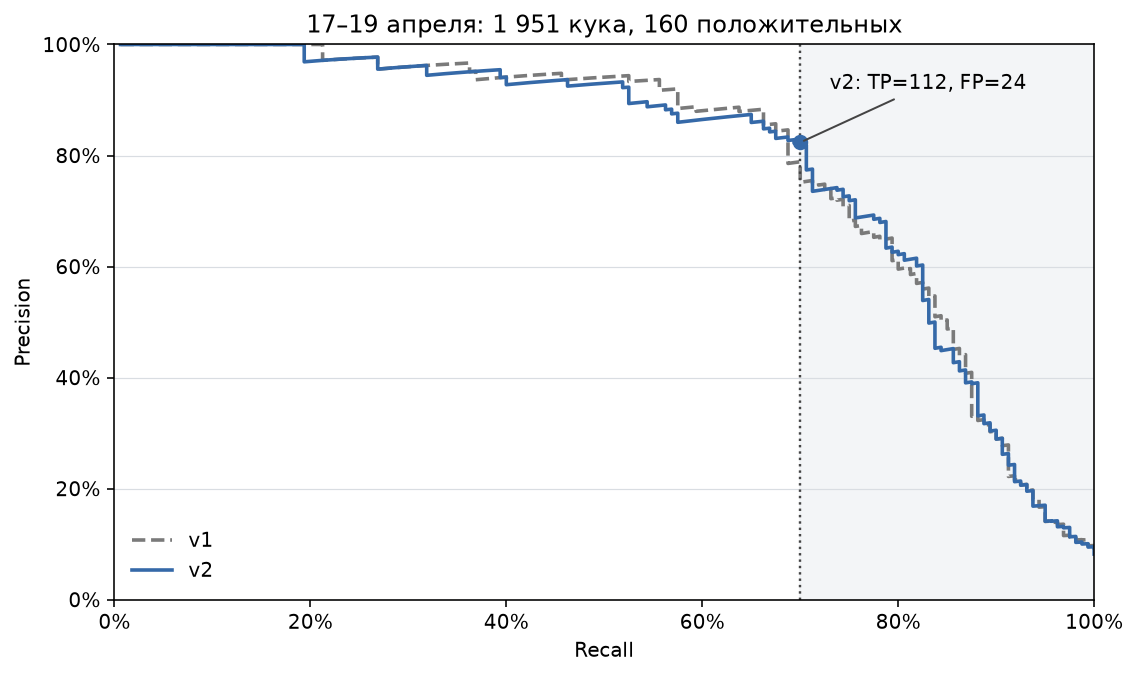

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Image
from metric import pr_curve

# График одного периода. Не смешиваем разные размеры обучения в одной кривой.
last_start, last_end = map(pd.Timestamp, FOLD_PERIODS[-1])
last = cv_predictions.window_start_ts.ge(last_start) & cv_predictions.window_start_ts.lt(last_end)
labels = cv_predictions.loc[last, "target"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.8))
for recipe, color, style in (("v1", "#7a7a7a", "--"), ("v2", "#3569a8", "-")):
    precision, recall = pr_curve(labels, cv_predictions.loc[last, recipe].to_numpy())
    ax.plot(recall, precision, color=color, linestyle=style, linewidth=1.8, label=recipe)
ax.axvspan(0.7, 1, color="#eceff2", alpha=0.6)
ax.axvline(0.7, color="#444444", linestyle=":", linewidth=1.2)
point = cv_report["results"]["v2"]["folds"][-1]["operating_point"]
ax.scatter([point["recall"]], [point["precision"]], color="#3569a8", s=45, zorder=3)
ax.annotate(f'v2: TP={point["true_positives"]}, FP={point["false_positives"]}',
            xy=(point["recall"], point["precision"]), xytext=(0.73, 0.92),
            arrowprops={"arrowstyle": "-", "color": "#444444"}, fontsize=10)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Recall", ylabel="Precision",
       title="17–19 апреля: 1 951 кука, 160 положительных")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", color="#d9dde2", linewidth=0.6)
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "validation_pr_curve.png", dpi=144, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "validation_pr_curve.png")))
plt.close(fig)

## 5. Обучаю финальный ансамбль и получаю submission.csv

Теперь обучаю выбранные четыре модели заново на всех 11 091 размеченных
куках. Веса по 0.25,
никакой подгонки порога или доли предсказанных ботов под test нет.

CSV записывается с тем же порядком строк и 17 значащими цифрами, что
в отправленном v2. Проверка SHA-256 ниже сравнивает весь файл, включая
представление чисел. При несовпадении выполнение остановится, а не подменит
новые предсказания приложенными ответами.

In [9]:
fitted = fit_final_models(features.train, data.train.target.to_numpy(dtype=int), OUTPUT_DIR, THREADS)
score = predict_ensemble(fitted, features.test)
submission = save_submission(data.test, score, SUBMISSION_PATH)
manifest = save_run_metadata(data, features, fitted, OUTPUT_DIR, SUBMISSION_PATH, THREADS)
submission_sha256 = assert_reference_submission(SUBMISSION_PATH)

print(f"Записан {SUBMISSION_PATH.name}: {len(submission)} строк, колонки {submission.columns.tolist()}")
print(f"SHA-256: {submission_sha256}")
print("Побайтово совпадает с отправленной v2")

Fit catboost_depth5: 11091 cookies / 250 features
Fit catboost_depth6: 11091 cookies / 250 features
Fit lightgbm_15: 11091 cookies / 472 features
Fit lightgbm_31: 11091 cookies / 472 features
Записан submission.csv: 4909 строк, колонки ['cookie_id', 'score']
SHA-256: 79097c046198354ff747ad08266702f6d0d8051d1305f556ceaa1c8da141ebea
Побайтово совпадает с отправленной v2


## 6. Перепроверяю независимость признаков и сохранённые модели

Заново читаю события и оставляю только тестовые куки. Эта сборка не видит
ни обучающих кук, ни их меток. Все 472 столбца должны совпасть с тестовой
частью общей сборки, не только итоговая метрика.

Затем загружаю четыре нативных файла моделей и повторяю предсказание.
Scores сравниваются с CSV с допуском 1e-12. Это отдельная проверка того,
что сохранённых файлов хватает для восстановления результата.

In [10]:
_, independent_test, raw_events = load_data(DATA_DIR)
test_raw = raw_events.loc[raw_events.cookie_id.isin(independent_test.cookie_id)].copy()
test_events, _ = prepare_events(test_raw, independent_test)
independent_features = build_advanced_features(test_events, independent_test).reset_index(drop=True)
pd.testing.assert_frame_equal(independent_features, features.test)

verification = verify_saved_result(DATA_DIR, OUTPUT_DIR, SUBMISSION_PATH, THREADS,
                                   test_features=independent_features)
print(f'Совпали все {verification["n_features"]} тестовых признака')
print(f'Восстановлены {verification["n_cookies"]} scores из {verification["n_models"]} моделей')

Совпали все 472 тестовых признака
Восстановлены 4909 scores из 4 моделей


In [11]:
import unittest

# Тесты на маленьких примерах: границы окон, будущие события, дубликаты,
# перемешивание, пустые куки, идентификаторы, метрика и формат CSV.
suite = unittest.defaultTestLoader.discover(str(ROOT / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful(), "Не все проверки прошли"

....................
----------------------------------------------------------------------
Ran 20 tests in 1.615s

OK


## Что получилось и где границы решения

Финальный `submission.csv` содержит 4 909 кук и совпадает с отправленной v2.
На скрытом тесте результат 0.82278, против 0.79361
у первой версии и 0.09391 у константного ответа.

Проверял и другие варианты: дополнительные seeds, веса классов,
регуляризацию, категории и новые признаки цепочек. После v2 устойчивого
прироста не нашлось, поэтому отправленный рецепт не менял.
История экспериментов описана в разделе «Что пробовал при выборе модели».

Разметка описывает известные сервисы сбора данных, а не всех возможных ботов.
В позднем проверочном блоке всего 160 положительных кук, и блок уже участвовал
в выборе решения. Перенос на новые сервисы и следующие месяцы отдельно
не проверен. Score служит прежде всего ранжированию: отдельно вероятности
не калибровались.

Для повторного обучения без Jupyter достаточно `python run.py`.
Он использует те же функции, но по умолчанию пропускает CV.
`python verify.py` отдельно проверяет результат и сохранённые модели.